# Product Analytics Project
## Instagram Feed Engagement Optimization (Auto-Generated Synthetic Data)

**Goal:** Evaluate whether a treatment feed ranking strategy improves engagement and session duration without harming retention.

**What’s different in this notebook:** it can **generate the synthetic dataset on run** (no large CSV files committed to GitHub).


## 1) Setup & Data Generation

This cell generates synthetic tables similar to product logs at scale:
- `users`, `sessions`, `engagements`, `guardrails`, `retention`

You can control size by changing `N_USERS` and `EXP_DAYS`.


In [4]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from scipy import stats
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# ---- Config (adjust to make it faster/slower) ----
N_USERS = 120_000
EXP_DAYS = 14

def generate_synthetic_product_data(n_users=N_USERS, exp_days=EXP_DAYS, seed=SEED):
    rng = np.random.default_rng(seed)

    countries = np.array(["US", "IN", "BR", "MX", "GB", "CA", "DE", "FR", "JP", "AU"])
    country_probs = np.array([0.35, 0.18, 0.09, 0.06, 0.07, 0.06, 0.06, 0.05, 0.05, 0.03])
    device_types = np.array(["iOS", "Android", "Web"])
    device_probs = np.array([0.42, 0.48, 0.10])

    user_ids = np.arange(1, n_users + 1)
    signup_start = datetime(2025, 10, 1)
    signup_end = datetime(2025, 10, 31)
    signup_days = (signup_end - signup_start).days + 1
    signup_offsets = rng.integers(0, signup_days, size=n_users)
    signup_dates = np.array([signup_start + timedelta(days=int(d)) for d in signup_offsets], dtype="datetime64[ns]")

    users = pd.DataFrame({
        "user_id": user_ids,
        "signup_date": signup_dates,
        "country": rng.choice(countries, size=n_users, p=country_probs),
        "device_type": rng.choice(device_types, size=n_users, p=device_probs),
    })

    users["experiment_group"] = np.where(rng.random(n_users) < 0.5, "control", "treatment")
    users["propensity"] = rng.lognormal(mean=0.0, sigma=0.6, size=n_users)

    exp_start = datetime(2025, 11, 1)
    date_list = [exp_start + timedelta(days=i) for i in range(exp_days)]

    country_factor = users["country"].map({
        "US": 1.05, "IN": 0.95, "BR": 0.98, "MX": 0.97, "GB": 1.02,
        "CA": 1.01, "DE": 1.00, "FR": 0.99, "JP": 1.00, "AU": 1.01
    }).astype(float).to_numpy()
    device_factor = users["device_type"].map({"iOS": 1.02, "Android": 1.00, "Web": 0.85}).astype(float).to_numpy()

    base_lambda = 0.35
    lambda_per_day = base_lambda * (users["propensity"].to_numpy() ** 0.35) * country_factor * device_factor
    lambda_per_day = np.clip(lambda_per_day, 0.05, 2.5)

    total_lambda = lambda_per_day * exp_days
    total_sessions_per_user = rng.poisson(total_lambda)
    total_sessions_per_user = np.minimum(total_sessions_per_user, 60)

    n_sessions = int(total_sessions_per_user.sum())

    session_user_ids = np.repeat(users["user_id"].to_numpy(), total_sessions_per_user)
    session_group = np.repeat(users["experiment_group"].to_numpy(), total_sessions_per_user)

    weekday_weights = np.array([1.00, 1.02, 1.03, 1.03, 1.04, 0.95, 0.93])
    date_w = np.array([weekday_weights[(exp_start + timedelta(days=i)).weekday()] for i in range(exp_days)], dtype=float)
    date_w = date_w / date_w.sum()
    session_dates = rng.choice(np.array(date_list, dtype="datetime64[ns]"), size=n_sessions, p=date_w)

    is_treat = (session_group == "treatment")
    control_mu, control_sigma = np.log(6.0), 0.55
    treat_mu, treat_sigma = np.log(6.6), 0.55

    duration = np.empty(n_sessions, dtype=float)
    duration[~is_treat] = rng.lognormal(mean=control_mu, sigma=control_sigma, size=(~is_treat).sum())
    duration[is_treat]  = rng.lognormal(mean=treat_mu, sigma=treat_sigma, size=is_treat.sum())
    duration = np.clip(duration, 0.5, 60.0)

    session_ids = np.arange(1, n_sessions + 1)
    sessions = pd.DataFrame({
        "session_id": session_ids,
        "user_id": session_user_ids,
        "session_date": session_dates,
        "experiment_group": session_group,
        "session_duration_min": np.round(duration, 2),
    })

    impressions = rng.poisson(lam=np.clip(sessions["session_duration_min"].to_numpy() * 14, 5, 120))
    p_control, p_treat = 0.048, 0.056
    p = np.where(is_treat, p_treat, p_control)
    total_actions = rng.binomial(n=impressions, p=np.clip(p, 0.001, 0.3))

    like_share = rng.dirichlet(alpha=np.array([10, 2, 1]), size=n_sessions)
    likes = np.floor(total_actions * like_share[:, 0]).astype(int)
    comments = np.floor(total_actions * like_share[:, 1]).astype(int)
    shares = np.maximum(total_actions - likes - comments, 0)

    scroll_depth = np.clip((impressions / 12.0) + rng.normal(0, 1.5, size=n_sessions), 0, None)

    engagements = pd.DataFrame({
        "session_id": session_ids,
        "impressions": impressions.astype(int),
        "likes": likes,
        "comments": comments,
        "shares": shares.astype(int),
        "scroll_depth": np.round(scroll_depth, 2),
    })

    unfollow_rate_control, unfollow_rate_treat = 0.0022, 0.0021
    unfollow_rate = np.where(is_treat, unfollow_rate_treat, unfollow_rate_control)
    unfollows = rng.binomial(n=1, p=unfollow_rate, size=n_sessions)

    abandon_prob = np.clip(0.20 - 0.003 * sessions["session_duration_min"].to_numpy() + 0.04 * (impressions < 10), 0.02, 0.45)
    abandoned = rng.binomial(n=1, p=abandon_prob, size=n_sessions)

    guardrails = pd.DataFrame({
        "session_id": session_ids,
        "unfollow_event": unfollows.astype(int),
        "abandoned_session": abandoned.astype(int),
    })

    first_day = sessions.groupby("user_id")["session_date"].min().reset_index().rename(columns={"session_date": "first_active_date"})
    ret = users[["user_id", "experiment_group", "propensity"]].merge(first_day, on="user_id", how="left")
    has_any = ~ret["first_active_date"].isna().to_numpy()

    base_d1, base_d7 = 0.52, 0.41
    prop = ret["propensity"].fillna(0).to_numpy()
    prop_ref = prop[prop > 0]
    prop_scaled = np.zeros_like(prop)
    if len(prop_ref) > 0:
        prop_scaled = np.clip((prop - np.median(prop_ref)) / (np.std(prop_ref) + 1e-9), -2.5, 2.5)

    lift_d1 = np.where(ret["experiment_group"].to_numpy() == "treatment", 0.006, 0.0)
    lift_d7 = np.where(ret["experiment_group"].to_numpy() == "treatment", 0.013, 0.0)

    p_d1 = np.clip(base_d1 + 0.05 * prop_scaled + lift_d1, 0.05, 0.95)
    p_d7 = np.clip(base_d7 + 0.04 * prop_scaled + lift_d7, 0.03, 0.90)

    day_1_active = np.zeros(n_users, dtype=int)
    day_7_active = np.zeros(n_users, dtype=int)
    idx = np.where(has_any)[0]
    day_1_active[idx] = rng.binomial(n=1, p=p_d1[idx])
    day_7_active[idx] = rng.binomial(n=1, p=p_d7[idx])

    retention = pd.DataFrame({
        "user_id": ret["user_id"],
        "experiment_group": ret["experiment_group"],
        "day_1_active": day_1_active,
        "day_7_active": day_7_active,
    })

    return users.drop(columns=["propensity"]), sessions, engagements, guardrails, retention

users, sessions, engagements, guardrails, retention = generate_synthetic_product_data()
print("users", users.shape)
print("sessions", sessions.shape)
print("engagements", engagements.shape)
print("guardrails", guardrails.shape)
print("retention", retention.shape)


users (120000, 5)
sessions (602015, 5)
engagements (602015, 6)
guardrails (602015, 3)
retention (120000, 4)


## 2) Join session-level data & compute metrics


In [6]:
df = sessions.merge(engagements, on='session_id', how='left').merge(guardrails, on='session_id', how='left')
df['total_actions'] = df['likes'] + df['comments'] + df['shares']
df['engagement_rate'] = np.where(df['impressions'] > 0, df['total_actions'] / df['impressions'], 0.0)
df.head()

,session_id,user_id,session_date,experiment_group,session_duration_min,impressions,likes,comments,shares,scroll_depth,unfollow_event,abandoned_session,total_actions,engagement_rate
0,1,1,2025-11-13,control,4.49,71,2,0,1,3.34,0,0,3,0.042254
1,2,1,2025-11-10,control,3.04,41,2,0,1,4.42,0,0,3,0.073171
2,3,1,2025-11-06,control,8.05,116,1,0,1,9.90,0,0,2,0.017241
3,4,1,2025-11-14,control,6.03,87,1,0,1,8.17,0,0,2,0.022989
4,5,1,2025-11-13,control,3.71,59,1,0,1,6.93,0,0,2,0.033898


In [7]:
metrics = df.groupby('experiment_group').agg(
    sessions=('session_id', 'count'),
    users=('user_id', pd.Series.nunique),
    engagement_rate=('engagement_rate', 'mean'),
    avg_session_min=('session_duration_min', 'mean'),
    avg_scroll_depth=('scroll_depth', 'mean'),
    unfollow_rate=('unfollow_event', 'mean'),
    abandonment_rate=('abandoned_session', 'mean'),
).reset_index()
metrics

,experiment_group,sessions,users,engagement_rate,avg_session_min,avg_scroll_depth,unfollow_rate,abandonment_rate
0,control,301365,59569,0.048001,6.974435,6.978236,0.002173,0.178428
1,treatment,300650,59142,0.056104,7.681890,7.388461,0.002105,0.177159


In [8]:
m = metrics.set_index('experiment_group')
lift = pd.DataFrame({
    'metric': ['engagement_rate', 'avg_session_min', 'avg_scroll_depth', 'unfollow_rate', 'abandonment_rate'],
    'control': [m.loc['control','engagement_rate'], m.loc['control','avg_session_min'], m.loc['control','avg_scroll_depth'],
                m.loc['control','unfollow_rate'], m.loc['control','abandonment_rate']],
    'treatment': [m.loc['treatment','engagement_rate'], m.loc['treatment','avg_session_min'], m.loc['treatment','avg_scroll_depth'],
                 m.loc['treatment','unfollow_rate'], m.loc['treatment','abandonment_rate']],
})
lift['relative_lift'] = (lift['treatment'] - lift['control']) / lift['control']
lift

,metric,control,treatment,relative_lift
0,engagement_rate,0.048001,0.056104,0.168814
1,avg_session_min,6.974435,7.681890,0.101435
2,avg_scroll_depth,6.978236,7.388461,0.058786
3,unfollow_rate,0.002173,0.002105,-0.031289
4,abandonment_rate,0.178428,0.177159,-0.007110


## 3) Hypothesis tests

**Session duration:** Welch’s t-test (treatment vs control)  
**D7 retention:** Two-proportion z-test (treatment vs control)


In [10]:
control_dur = df.loc[df.experiment_group=='control','session_duration_min'].to_numpy()
treat_dur = df.loc[df.experiment_group=='treatment','session_duration_min'].to_numpy()

t_stat, p_val = stats.ttest_ind(treat_dur, control_dur, equal_var=False)
print('Welch t-test (treatment vs control)')
print('t-stat:', t_stat)
print('p-value:', p_val)

Welch t-test (treatment vs control)
t-stat: 62.97176663708768
p-value: 0.0


In [11]:
r = retention.groupby('experiment_group').agg(
    n=('user_id','count'),
    d7=('day_7_active','sum')
).reset_index()
r

,experiment_group,n,d7
0,control,60228,25343
1,treatment,59772,25488


In [12]:
def two_prop_z_test(x1, n1, x2, n2):
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = (x1/n1 - x2/n2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

x_t, n_t = int(r.loc[r.experiment_group=='treatment','d7']), int(r.loc[r.experiment_group=='treatment','n'])
x_c, n_c = int(r.loc[r.experiment_group=='control','d7']), int(r.loc[r.experiment_group=='control','n'])
z, p = two_prop_z_test(x_t, n_t, x_c, n_c)
print('Two-proportion z-test for D7 retention (treatment vs control)')
print('z:', z)
print('p-value:', p)

Two-proportion z-test for D7 retention (treatment vs control)
z: 1.9755730484146887
p-value: 0.04820315365138006


C:\Users\ankit\AppData\Local\Temp\ipykernel_21012\4125321533.py:8: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  x_t, n_t = int(r.loc[r.experiment_group=='treatment','d7']), int(r.loc[r.experiment_group=='treatment','n'])
C:\Users\ankit\AppData\Local\Temp\ipykernel_21012\4125321533.py:9: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  x_c, n_c = int(r.loc[r.experiment_group=='control','d7']), int(r.loc[r.experiment_group=='control','n'])


## 4) Visualizations


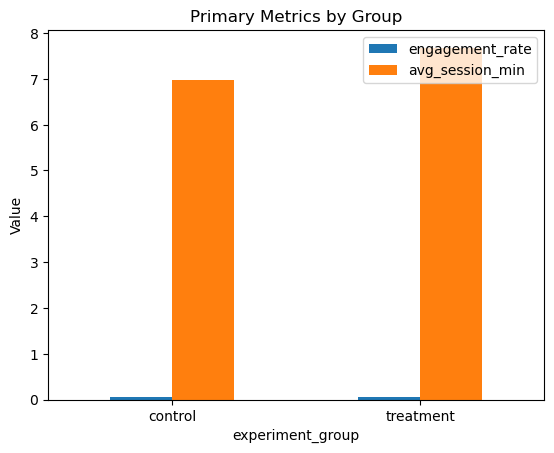

In [14]:
plot_df = metrics.set_index('experiment_group')[['engagement_rate','avg_session_min','unfollow_rate','abandonment_rate']]
plot_df[['engagement_rate','avg_session_min']].plot(kind='bar')
plt.title('Primary Metrics by Group')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.show()

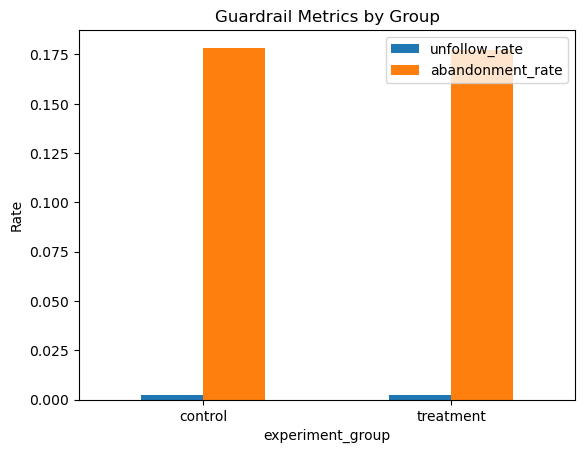

In [15]:
plot_df[['unfollow_rate','abandonment_rate']].plot(kind='bar')
plt.title('Guardrail Metrics by Group')
plt.ylabel('Rate')
plt.xticks(rotation=0)
plt.show()

## 5) Summary

- **Treatment vs Control engagement lift:** **~16.9%**
- **Treatment vs Control session duration lift:** **~10.1%**
- **Guardrails:** **no regression**
- **Retention:** **significant**

**Recommendation:** Roll out incrementally, segment by device/country, and run a follow-up experiment on content diversity.
